In [42]:
import pathlib

import pandas as pd
import numpy as np
import torch

from sklearn.metrics import roc_auc_score, average_precision_score
from rdkit import Chem
from rdkit.Chem import Draw
from matplotlib import pyplot as plt
from torch_geometric.nn import MessagePassing
from captum.attr import IntegratedGradients, Saliency
from rdkit.Chem import rdMolAlign
from rdkit.Chem import AllChem

from mpnn import visualize_all_activations, AllNonZeroReadout, MoleculeFDetector
from highlight_smarts import highlight_atoms_in_mol, visualize_smarts_match
from krfp_models import krfp_models, name_to_post_smarts, name_to_pre_smarts
from mpnn import one_hot_encode, smiles_to_torch, mol_to_torch, MoleculeGDetector
from datavis import visualize_atom_importance, visualize_atom_importance_from_mol
from mpnn.mpnn_arch import AllNonZeroMaxReadout, AllNonZeroSumReadout

from xai_methods import IGAttributionMethod, SaliencyAttributionMethod
from xai_methods.captum_attributions import ShapleyValueSamplingAttributionMethod


In [2]:
# We also need to create a table showing ROC's, AP's and other metrics for explainers.

artifact_path = pathlib.Path("artifacts/explainability_method_tester/20260429_221014")  # R2
#artifact_path = pathlib.Path("artifacts/explainability_method_tester/20260501_115658")  # R1

whitebox_to_path = {}

for directory in artifact_path.iterdir():
    if directory.is_dir():
        whitebox_to_path[directory.name] = directory

whitebox_to_positive_eval = {}

for whitebox, path in whitebox_to_path.items():
    positive_eval_path = path / "positive_explainability_results.csv"

    df = pd.read_csv(positive_eval_path)
    whitebox_to_positive_eval[whitebox] = df

In [65]:
all_shap_results = []
all_shap_whitebox_origin_labels = []
all_shap_molecules = []

for whitebox, df in sorted(whitebox_to_positive_eval.items(), key=lambda x: x[0]):
    # Just to see it compared to the performance of IG in terms of being ideal 
    ig_nonideals = df["Integrated Gradients_auroc"].dropna().tolist().count(1.0)
    ig_total = len(df["Integrated Gradients_auroc"].dropna().tolist())

    df = df.dropna(subset=["SHAP Sampling_auroc"])  # Drop rows where SHAP Sampling_auroc is NaN
    shap_results = df["SHAP Sampling_auroc"].tolist()
    all_shap_results.extend(shap_results)

    smiles = df["SMILES"].tolist()
    all_shap_molecules.extend(smiles)

    whitebox_origin_labels = [whitebox] * len(shap_results)
    all_shap_whitebox_origin_labels.extend(whitebox_origin_labels)

    nonideals = shap_results.count(1.0)
    total = len(shap_results)
    print(f"{whitebox} (SHAP): {nonideals}/{total} ({nonideals / total:.2%})")
    print(f"{whitebox} (IG): {ig_nonideals}/{ig_total} ({ig_nonideals / ig_total:.2%})")

shap_results_df = pd.DataFrame({
    "Whitebox": all_shap_whitebox_origin_labels,
    "SMILES": all_shap_molecules,
    "AUROC": all_shap_results
})


MoleculeCDetector (SHAP): 85/100 (85.00%)
MoleculeCDetector (IG): 7621/7660 (99.49%)
MoleculeEDetector (SHAP): 57/94 (60.64%)
MoleculeEDetector (IG): 236/236 (100.00%)
MoleculeFDetector (SHAP): 3/22 (13.64%)
MoleculeFDetector (IG): 22/22 (100.00%)
MoleculeGDetector (SHAP): 60/100 (60.00%)
MoleculeGDetector (IG): 964/1137 (84.78%)
MoleculeHDetector (SHAP): 20/31 (64.52%)
MoleculeHDetector (IG): 29/31 (93.55%)
MoleculeIDetector (SHAP): 78/100 (78.00%)
MoleculeIDetector (IG): 9984/9984 (100.00%)
MoleculeJDetector (SHAP): 97/100 (97.00%)
MoleculeJDetector (IG): 9990/9990 (100.00%)
MoleculeKDetector (SHAP): 88/100 (88.00%)
MoleculeKDetector (IG): 9996/9996 (100.00%)
MoleculeLDetector (SHAP): 97/100 (97.00%)
MoleculeLDetector (IG): 9989/9989 (100.00%)
MoleculeMDetector (SHAP): 95/100 (95.00%)
MoleculeMDetector (IG): 9989/9989 (100.00%)
MoleculeNDetector (SHAP): 98/100 (98.00%)
MoleculeNDetector (IG): 9999/9999 (100.00%)
MoleculeODetector (SHAP): 100/100 (100.00%)
MoleculeODetector (IG): 9999

In [19]:
shap_results_df_fails = shap_results_df[shap_results_df["AUROC"] != 1.0]
shap_results_df_ok = shap_results_df[shap_results_df["AUROC"] == 1.0]

In [13]:
# Just to be sure: Model always predicts (empirically) 0 or 1 for R2

testing_logs_path = pathlib.Path("testing_artifacts/20260429_182622")

for csv_file in testing_logs_path.glob("*.csv"):
    df = pd.read_csv(csv_file)
    df = df.dropna(subset=["PRED"])  # Drop rows where PRED is NaN
    values = df["PRED"]

    weird_preds = values[(values != 0.0) & (values != 1.0)]

    print("Weird preds", len(weird_preds), weird_preds)

    one_preds = values[values == 1.0]
    zero_preds = values[values == 0.0]

    print("One preds", len(one_preds))
    print("Zero preds", len(zero_preds))
    print("Total preds", len(values))

    assert len(weird_preds) == 0, f"Found weird predictions in {csv_file}: {weird_preds}"
    assert len(one_preds) + len(zero_preds) == len(
        values), f"Total predictions do not match sum of one and zero predictions in {csv_file}"

Weird preds 0 Series([], Name: PRED, dtype: float64)
One preds 4999997
Zero preds 9729152
Total preds 14729149
Weird preds 0 Series([], Name: PRED, dtype: float64)
One preds 24
Zero preds 6493642
Total preds 6493666
Weird preds 0 Series([], Name: PRED, dtype: float64)
One preds 1970527
Zero preds 5682813
Total preds 7653340
Weird preds 0 Series([], Name: PRED, dtype: float64)
One preds 34
Zero preds 5067180
Total preds 5067214
Weird preds 0 Series([], Name: PRED, dtype: float64)
One preds 3376759
Zero preds 7726781
Total preds 11103540
Weird preds 0 Series([], Name: PRED, dtype: float64)
One preds 4999995
Zero preds 5227272
Total preds 10227267
Weird preds 0 Series([], Name: PRED, dtype: float64)
One preds 248
Zero preds 5113024
Total preds 5113272
Weird preds 0 Series([], Name: PRED, dtype: float64)
One preds 4999998
Zero preds 5011992
Total preds 10011990
Weird preds 0 Series([], Name: PRED, dtype: float64)
One preds 886073
Zero preds 9138918
Total preds 10024991
Weird preds 0 Series

In [22]:
ok_molecules = shap_results_df_ok["SMILES"].tolist()
fail_molecules = shap_results_df_fails["SMILES"].tolist()

ok_patterns = shap_results_df_ok["Whitebox"].tolist()
fail_patterns = shap_results_df_fails["Whitebox"].tolist()

ok_patterns_smarts = [name_to_pre_smarts[pattern] for pattern in ok_patterns]
fail_patterns_smarts = [name_to_pre_smarts[pattern] for pattern in fail_patterns]

In [24]:
from rdkit import Chem

ok_pattern_sizes = [Chem.MolFromSmarts(smarts).GetNumAtoms() for smarts in ok_patterns_smarts]
fail_pattern_sizes = [Chem.MolFromSmarts(smarts).GetNumAtoms() for smarts in fail_patterns_smarts]

ok_mols = [Chem.MolFromSmiles(smiles) for smiles in ok_molecules]
fail_mols = [Chem.MolFromSmiles(smiles) for smiles in fail_molecules]

ok_mols = [Chem.RemoveAllHs(mol) for mol in ok_mols]
fail_mols = [Chem.RemoveAllHs(mol) for mol in fail_mols]

ok_mol_sizes = [mol.GetNumAtoms() for mol in ok_mols]
fail_mol_sizes = [mol.GetNumAtoms() for mol in fail_mols]

In [25]:
plot_df = pd.DataFrame({
    "Pattern Size": ok_pattern_sizes + fail_pattern_sizes,
    "Molecule Size": ok_mol_sizes + fail_mol_sizes,
    "SHAP AUROC": [1.0] * len(ok_pattern_sizes) + [0.0] * len(fail_pattern_sizes)
})


<Axes: xlabel='Molecule Size', ylabel='Pattern Size'>

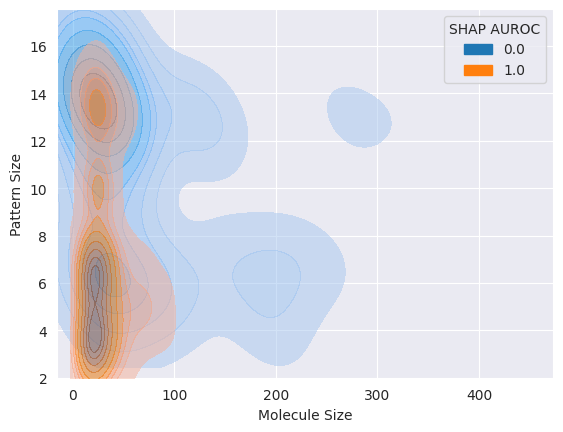

In [31]:
import seaborn as sns

sns.kdeplot(
    data=plot_df, x="Molecule Size", y="Pattern Size", hue="SHAP AUROC", common_norm=False, fill=True, alpha=0.5,
    cut=True
)

In [45]:
# This wasn't of much use. 

mol_f_smiles = shap_results_df[shap_results_df["Whitebox"] == "MoleculeFDetector"]

In [46]:
mol_f_mols = [Chem.MolFromSmiles(smiles) for smiles in mol_f_smiles["SMILES"].tolist()]
mol_f_mols = [Chem.RemoveAllHs(mol) for mol in mol_f_mols]

In [54]:
# Attribute them
model = MoleculeFDetector()

method = ShapleyValueSamplingAttributionMethod(
    model=model,
    model_smarts=name_to_post_smarts["MoleculeFDetector"],
    positive_smiles=[],
    negative_smiles=[],
    n_samples=100,
)

In [57]:
from sklearn.metrics import roc_auc_score

aurocs_n_samples_100 = []

for mol in mol_f_mols:
    x, edge_index, edge_features = mol_to_torch(mol)

    attr, _ = method.explain(
        x,
        edge_features,
        edge_index,
    )

    attr = torch.sum(torch.abs(attr), dim=1).detach().numpy()

    ground_truth_list = highlight_atoms_in_mol(mol, name_to_pre_smarts["MoleculeFDetector"])
    ground_truth_real = [1 if atom.GetIdx() in ground_truth_list else 0 for atom in mol.GetAtoms()]
    ground_truth_real = np.array(ground_truth_real)

    auroc = roc_auc_score(ground_truth_real, attr)

    aurocs_n_samples_100.append(auroc)


In [60]:
perfect = [auroc == 1.0 for auroc in aurocs_n_samples_100]
perfect_count = sum(perfect)

print("Perfect attributions (AUROC=1.0):", perfect_count)

Perfect attributions (AUROC=1.0): 4


In [61]:
# Now redo the same, but with bigger sampler count

method = ShapleyValueSamplingAttributionMethod(
    model=model,
    model_smarts=name_to_post_smarts["MoleculeFDetector"],
    positive_smiles=[],
    negative_smiles=[],
    n_samples=500,
)

aurocs_n_samples_500 = []

for mol in mol_f_mols:
    x, edge_index, edge_features = mol_to_torch(mol)

    attr, _ = method.explain(
        x,
        edge_features,
        edge_index,
    )

    attr = torch.sum(torch.abs(attr), dim=1).detach().numpy()

    ground_truth_list = highlight_atoms_in_mol(mol, name_to_pre_smarts["MoleculeFDetector"])
    ground_truth_real = [1 if atom.GetIdx() in ground_truth_list else 0 for atom in mol.GetAtoms()]
    ground_truth_real = np.array(ground_truth_real)

    auroc = roc_auc_score(ground_truth_real, attr)

    aurocs_n_samples_500.append(auroc)

In [63]:
perfect_500 = [auroc == 1.0 for auroc in aurocs_n_samples_500]
perfect_count_500 = sum(perfect_500)

print("Perfect attributions (AUROC=1.0):", perfect_count_500)

Perfect attributions (AUROC=1.0): 22
